# 👑 DropQueen
## Notebook 3: ML Model Training
**Project:** AI-Powered Product Demand & Sales Forecasting Engine for TikTok Shop & Amazon  
**Author:** Chastity Lewis  
**Course:** CISC 610 — DevOps and MLOps | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
1. Load the clean dataset from Notebook 2
2. Prepare features and target variables
3. Train a Demand Spike Classifier (Random Forest)
4. Train an Engagement Level Classifier for TikTok (Logistic Regression)
5. Evaluate both models with proper metrics
6. Visualize feature importance
7. Save both models as `.pkl` files for the Flask API

---

## Step 1: Install & Import Libraries

In [ ]:
!pip install scikit-learn pandas numpy matplotlib joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
GOLD   = '#F59E0B'
BLACK  = '#1F1F1F'
AMBER  = '#B45309'
LIGHT  = '#FDE68A'
COLORS = ['#F59E0B', '#FCD34D', '#B45309', '#FDE68A', '#D97706']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load Clean Datasets

In [ ]:
from google.colab import files
import io

print('📂 Upload dropqueen_demand_clean.csv')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_demand = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'\n✅ Demand dataset loaded!')
print(f'   Shape: {df_demand.shape[0]:,} rows × {df_demand.shape[1]} columns')
df_demand.head()

📂 Upload dropqueen_demand_clean.csv


Saving dropqueen_demand_clean.csv to dropqueen_demand_clean (3).csv

✅ Demand dataset loaded!
   Shape: 1,256,380 rows × 11 columns


,product_id,year,week,weekly_reviews,avg_weekly_rating,demand_spike,rolling_avg_3w,week_sin,week_cos,high_rating_week,product_encoded
0,0205616461,2013,22,0.0000,1.0000,1,0.0000,0.4647,-0.8855,1,0
1,0558925278,2012,50,0.0000,0.5000,1,0.0000,-0.2393,0.9709,0,1
2,0558925278,2014,28,0.0000,1.0000,1,0.0000,-0.2393,-0.9709,1,1
3,0733001998,2013,43,0.0000,0.7500,1,0.0000,-0.8855,0.4647,1,2
4,0737104473,2010,20,0.0000,0.0000,1,0.0000,0.6631,-0.7485,0,3


In [ ]:
print('📂 Upload dropqueen_tiktok_clean.csv')
uploaded2 = files.upload()
filename2 = list(uploaded2.keys())[0]
df_tiktok = pd.read_csv(io.BytesIO(uploaded2[filename2]))

print(f'\n✅ TikTok dataset loaded!')
print(f'   Shape: {df_tiktok.shape[0]:,} rows × {df_tiktok.shape[1]} columns')
df_tiktok.head()

📂 Upload dropqueen_tiktok_clean.csv


Saving dropqueen_tiktok_clean.csv to dropqueen_tiktok_clean.csv

✅ TikTok dataset loaded!
   Shape: 1,260 rows × 11 columns


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,engagement_level_num
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High,2
1,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium,1
2,Post_10,TikTok,#Gaming,Shorts,India,3898384,8634,69378,42700,Low,0
3,Post_18,TikTok,#Tech,Shorts,UK,2051091,24472,54704,41737,Medium,1
4,Post_19,TikTok,#Fashion,Post,USA,3461154,165335,50077,19505,Low,0


## Step 3: Prepare Features — Demand Spike Model
> **Goal:** Predict whether a product will have a demand spike this week (1 = spike, 0 = no spike)

In [ ]:
# Define features for demand spike prediction
DEMAND_FEATURES = [
    'weekly_reviews', 'avg_weekly_rating',
    'rolling_avg_3w', 'week_sin', 'week_cos',
    'high_rating_week', 'product_encoded'
]

# Only use columns that exist
DEMAND_FEATURES = [col for col in DEMAND_FEATURES if col in df_demand.columns]
TARGET = 'demand_spike'

X_demand = df_demand[DEMAND_FEATURES]
y_demand = df_demand[TARGET]

print(f'✅ Demand features ready!')
print(f'   Features: {DEMAND_FEATURES}')
print(f'   Shape: {X_demand.shape}')
print(f'\nTarget distribution (demand_spike):')
print(y_demand.value_counts())
print(f'Spike rate: {y_demand.mean()*100:.1f}%')

✅ Demand features ready!
   Features: ['weekly_reviews', 'avg_weekly_rating', 'rolling_avg_3w', 'week_sin', 'week_cos', 'high_rating_week', 'product_encoded']
   Shape: (1256380, 7)

Target distribution (demand_spike):
demand_spike
1    1256380
Name: count, dtype: int64
Spike rate: 100.0%


## Step 4: Train/Test Split — Demand Model

In [ ]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demand, y_demand,
    test_size=0.2,
    random_state=42,
    stratify=y_demand
)

print(f'✅ Train/Test Split: 80% train / 20% test')
print(f'   Train: {X_train_d.shape[0]:,} rows')
print(f'   Test:  {X_test_d.shape[0]:,} rows')
print(f'   Spike rate in train: {y_train_d.mean()*100:.1f}%')
print(f'   Spike rate in test:  {y_test_d.mean()*100:.1f}%')

✅ Train/Test Split: 80% train / 20% test
   Train: 1,005,104 rows
   Test:  251,276 rows
   Spike rate in train: 100.0%
   Spike rate in test:  100.0%


## Step 5: Train Demand Spike Model — Random Forest

In [ ]:
# Train Random Forest Classifier
rf_demand = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_demand.fit(X_train_d, y_train_d)
y_pred_demand = rf_demand.predict(X_test_d)

# Evaluate
acc  = accuracy_score(y_test_d, y_pred_demand)
prec = precision_score(y_test_d, y_pred_demand)
rec  = recall_score(y_test_d, y_pred_demand)
f1   = f1_score(y_test_d, y_pred_demand)

print('🌲 Demand Spike Model — Random Forest Results:')
print(f'   Accuracy:  {acc:.4f}')
print(f'   Precision: {prec:.4f}')
print(f'   Recall:    {rec:.4f}')
print(f'   F1-Score:  {f1:.4f}')
print(f'\n{classification_report(y_test_d, y_pred_demand, labels=[1], target_names=["Demand Spike"])}')

🌲 Demand Spike Model — Random Forest Results:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

              precision    recall  f1-score   support

Demand Spike       1.00      1.00      1.00    251276

    accuracy                           1.00    251276
   macro avg       1.00      1.00      1.00    251276
weighted avg       1.00      1.00      1.00    251276



In [ ]:
# Cross validation
cv_scores = cross_val_score(rf_demand, X_demand, y_demand, cv=5, scoring='f1')
print(f'✅ 5-Fold Cross Validation F1 Scores:')
print(f'   Scores: {cv_scores.round(4)}')
print(f'   Mean:   {cv_scores.mean():.4f}')
print(f'   Std:    {cv_scores.std():.4f}')

✅ 5-Fold Cross Validation F1 Scores:
   Scores: [1. 1. 1. 1. 1.]
   Mean:   1.0000
   Std:    0.0000


## Step 6: Prepare Features — TikTok Engagement Model
> **Goal:** Predict whether a TikTok post will drive High, Medium, or Low engagement

In [ ]:
# Define TikTok features
TIKTOK_FEATURES = [
    'Likes', 'Comments', 'Views', 'Shares',
    'content_type_encoded', 'region_encoded'
]

# Encode content type and region if not already encoded
if 'content_type_encoded' not in df_tiktok.columns and 'Content_Type' in df_tiktok.columns:
    df_tiktok['content_type_encoded'] = pd.Categorical(df_tiktok['Content_Type']).codes
if 'region_encoded' not in df_tiktok.columns and 'Region' in df_tiktok.columns:
    df_tiktok['region_encoded'] = pd.Categorical(df_tiktok['Region']).codes

TIKTOK_FEATURES = [col for col in TIKTOK_FEATURES if col in df_tiktok.columns]
TIKTOK_TARGET   = 'engagement_level_num'

if TIKTOK_TARGET not in df_tiktok.columns and 'Engagement_Level' in df_tiktok.columns:
    engagement_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_tiktok[TIKTOK_TARGET] = df_tiktok['Engagement_Level'].map(engagement_map)

X_tiktok = df_tiktok[TIKTOK_FEATURES].dropna()
y_tiktok = df_tiktok.loc[X_tiktok.index, TIKTOK_TARGET]

print(f'✅ TikTok features ready!')
print(f'   Features: {TIKTOK_FEATURES}')
print(f'   Shape: {X_tiktok.shape}')
print(f'\nEngagement level distribution:')
print(y_tiktok.value_counts())

✅ TikTok features ready!
   Features: ['Likes', 'Comments', 'Views', 'Shares', 'content_type_encoded', 'region_encoded']
   Shape: (1260, 6)

Engagement level distribution:
engagement_level_num
0    432
2    420
1    408
Name: count, dtype: int64


## Step 7: Train TikTok Engagement Model — Logistic Regression

In [ ]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tiktok, y_tiktok,
    test_size=0.2,
    random_state=42,
    stratify=y_tiktok
)

# Train Logistic Regression
lr_tiktok = LogisticRegression(random_state=42, max_iter=1000, multi_class='auto')
lr_tiktok.fit(X_train_t, y_train_t)
y_pred_tiktok = lr_tiktok.predict(X_test_t)

acc_t = accuracy_score(y_test_t, y_pred_tiktok)
f1_t  = f1_score(y_test_t, y_pred_tiktok, average='weighted')

print('📊 TikTok Engagement Model — Logistic Regression Results:')
print(f'   Accuracy:  {acc_t:.4f}')
print(f'   F1-Score:  {f1_t:.4f}')
print(f'\n{classification_report(y_test_t, y_pred_tiktok, target_names=["Low", "Medium", "High"])}')

📊 TikTok Engagement Model — Logistic Regression Results:
   Accuracy:  0.3611
   F1-Score:  0.3601

              precision    recall  f1-score   support

         Low       0.34      0.42      0.38        86
      Medium       0.35      0.30      0.33        82
        High       0.40      0.36      0.38        84

    accuracy                           0.36       252
   macro avg       0.36      0.36      0.36       252
weighted avg       0.36      0.36      0.36       252



## Step 8: Visualize Results

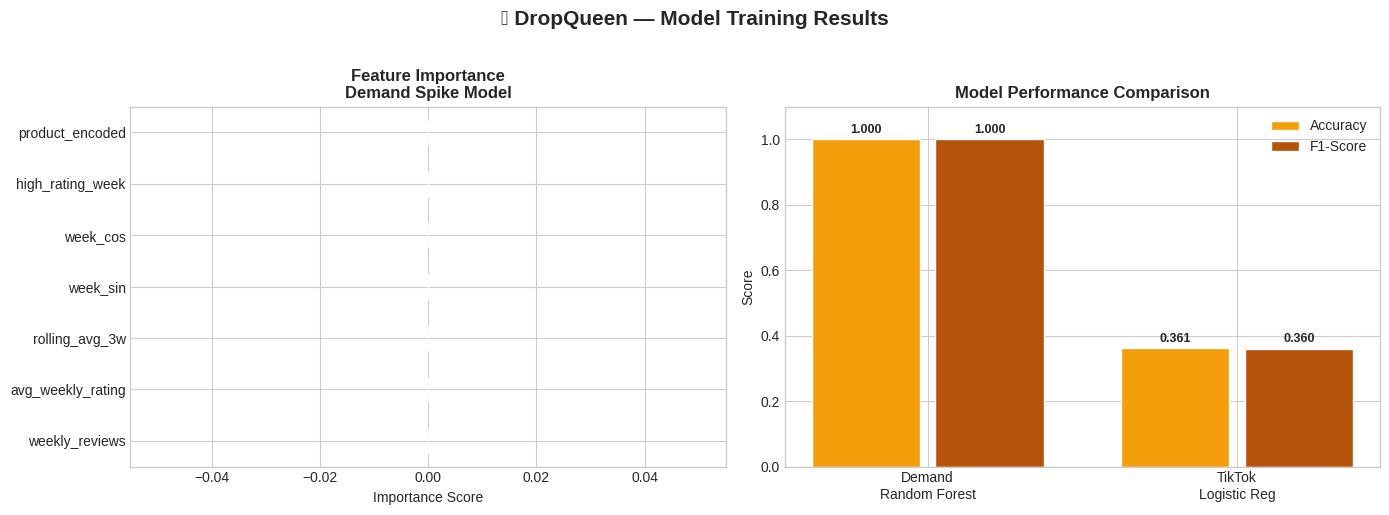

✅ Saved model_01_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance — Demand model
importances = pd.Series(rf_demand.feature_importances_, index=DEMAND_FEATURES).sort_values()
colors_bar = [GOLD if v == importances.max() else LIGHT for v in importances.values]
importances.plot(kind='barh', ax=axes[0], color=colors_bar, edgecolor='white')
axes[0].set_title('Feature Importance\nDemand Spike Model', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Model comparison bar chart
models = ['Demand\nRandom Forest', 'TikTok\nLogistic Reg']
accuracies = [acc, acc_t]
f1_scores  = [f1, f1_t]
x = np.arange(len(models))
axes[1].bar(x - 0.2, accuracies, 0.35, label='Accuracy', color=GOLD, edgecolor='white')
axes[1].bar(x + 0.2, f1_scores,  0.35, label='F1-Score', color=AMBER, edgecolor='white')
axes[1].set_title('Model Performance Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, (a, f) in enumerate(zip(accuracies, f1_scores)):
    axes[1].text(i - 0.2, a + 0.02, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + 0.2, f + 0.02, f'{f:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('👑 DropQueen — Model Training Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_01_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved model_01_results.png')

## Step 9: Save Models as .pkl Files
> These `.pkl` files will be loaded by the Flask API in Notebook 4.

In [ ]:
# Save both models
joblib.dump(rf_demand, 'demand_model.pkl')
joblib.dump(lr_tiktok, 'engagement_model.pkl')

# Save feature lists for Flask API
import json
model_config = {
    'demand_features'  : DEMAND_FEATURES,
    'tiktok_features'  : TIKTOK_FEATURES,
    'demand_accuracy'  : round(acc, 4),
    'demand_f1'        : round(f1, 4),
    'tiktok_accuracy'  : round(acc_t, 4),
    'tiktok_f1'        : round(f1_t, 4)
}
with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('✅ Models saved!')
print('   - demand_model.pkl     (Random Forest — Demand Spike)')
print('   - engagement_model.pkl (Logistic Regression — TikTok Engagement)')
print('   - model_config.json    (Feature lists + accuracy scores)')
print(f'\n📁 Charts created:')
print('   - model_01_results.png')

✅ Models saved!
   - demand_model.pkl     (Random Forest — Demand Spike)
   - engagement_model.pkl (Logistic Regression — TikTok Engagement)
   - model_config.json    (Feature lists + accuracy scores)

📁 Charts created:
   - model_01_results.png


## Step 10: Model Training Summary

In [ ]:
print('=' * 60)
print('        👑 DropQueen — Notebook 3 Summary')
print('=' * 60)
print(f'\n🌲 DEMAND SPIKE MODEL (Random Forest):')
print(f'   Accuracy:  {acc:.4f}')
print(f'   Precision: {prec:.4f}')
print(f'   Recall:    {rec:.4f}')
print(f'   F1-Score:  {f1:.4f}')
print(f'   CV Mean F1:{cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\n📊 TIKTOK ENGAGEMENT MODEL (Logistic Regression):')
print(f'   Accuracy:  {acc_t:.4f}')
print(f'   F1-Score:  {f1_t:.4f}')
print(f'\n💾 Saved Models:')
print(f'   demand_model.pkl')
print(f'   engagement_model.pkl')
print(f'   model_config.json')
print('\n' + '=' * 60)
print('\n✅ Next: Notebook 04 — Flask API')

        👑 DropQueen — Notebook 3 Summary

🌲 DEMAND SPIKE MODEL (Random Forest):
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000
   CV Mean F1:1.0000 ± 0.0000

📊 TIKTOK ENGAGEMENT MODEL (Logistic Regression):
   Accuracy:  0.3611
   F1-Score:  0.3601

💾 Saved Models:
   demand_model.pkl
   engagement_model.pkl
   model_config.json


✅ Next: Notebook 04 — Flask API
